# 14-Day Window: LightGBM vs XGBoost
This notebook trains two models (LGBM and XGB) on the `lgbm_14` dataset, compares MAE/SMAPE/BIAS/RMSE, and visualizes predictions and residuals.

## 1) Imports and Paths
This cell imports required libraries and defines project/data/report paths.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

RANDOM_SEED = 42
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'processed' / 'lgbm_14'
REPORTS_DIR = ROOT / 'artifacts' / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print('DATA_DIR:', DATA_DIR)
print('REPORTS_DIR:', REPORTS_DIR)

DATA_DIR: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\data\processed\lgbm_14
REPORTS_DIR: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports


## 2) Load Train/Val/Test
This cell loads the 14-day processed splits and performs a quick sanity check on sizes and nulls.

In [2]:
train_df = pd.read_csv(DATA_DIR / 'train.csv')
val_df = pd.read_csv(DATA_DIR / 'val.csv')
test_df = pd.read_csv(DATA_DIR / 'test.csv')

for df in [train_df, val_df, test_df]:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

summary = pd.DataFrame([
    {'split': 'train', 'rows': len(train_df), 'cols': train_df.shape[1], 'null_cells': int(train_df.isna().sum().sum())},
    {'split': 'val', 'rows': len(val_df), 'cols': val_df.shape[1], 'null_cells': int(val_df.isna().sum().sum())},
    {'split': 'test', 'rows': len(test_df), 'cols': test_df.shape[1], 'null_cells': int(test_df.isna().sum().sum())},
])
summary

,split,rows,cols,null_cells
0,train,67539,37,0
1,val,14370,37,0
2,test,15807,37,0


## 3) Features and Target
This cell defines target/feature columns and identifies numeric vs categorical features for preprocessing.

In [3]:
target_col = 'aggregated_sales_14'
feature_cols = [c for c in train_df.columns if c not in [
    target_col, 'date', 'item_id',
    'sales_lag_2', 'sales_lag_4',
    'sales_roll_mean_2', 'sales_roll_mean_4',
    'sales_roll_std_4'
    ]]

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()
X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

categorical_features = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(X_train[c])]
numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(X_train[c])]

print('Target:', target_col)
print('Feature count:', len(feature_cols))
print('Numeric:', len(numeric_features), 'Categorical:', len(categorical_features))
print('Categorical features:', categorical_features)

Target: aggregated_sales_14
Feature count: 29
Numeric: 29 Categorical: 0
Categorical features: []


## 4) Build Pipelines and Metric Helpers
This cell creates a common preprocessor, defines LGBM/XGB pipelines, and helper functions for SMAPE and evaluation.

In [4]:
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return float(100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom))

def compute_metrics(y_true, y_pred):
    return {
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'SMAPE': float(smape(y_true, y_pred)),
        'BIAS': float(np.mean(np.asarray(y_pred) - np.asarray(y_true))),
    }

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

lgbm_model = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', LGBMRegressor(random_state=RANDOM_SEED, n_estimators=400, learning_rate=0.03, num_leaves=64))
])

xgb_model = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', XGBRegressor(
        random_state=RANDOM_SEED,
        n_estimators=600,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='reg:squarederror',
        tree_method='hist'
    ))
])

## 5) Train Both Models and Compare Metrics
This cell trains LGBM and XGB, computes MAE/SMAPE/BIAS/RMSE on validation and test sets, and shows a comparison table.

In [5]:
models = {
    'LightGBM_14d': lgbm_model,
    'XGBoost_14d': xgb_model,
}

preds_val = {}
preds_test = {}
rows = []

for name, model in models.items():
    model.fit(X_train, y_train)

    p_val = model.predict(X_val)
    p_test = model.predict(X_test)

    preds_val[name] = p_val
    preds_test[name] = p_test

    m_val = compute_metrics(y_val, p_val)
    m_test = compute_metrics(y_test, p_test)

    rows.append({'split': 'val', 'model': name, **m_val})
    rows.append({'split': 'test', 'model': name, **m_test})

metrics_df = pd.DataFrame(rows).sort_values(['split', 'SMAPE']).reset_index(drop=True)
metrics_df

c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", l

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008095 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2962
[LightGBM] [Info] Number of data points in the train set: 67539, number of used features: 28
[LightGBM] [Info] Start training from score 28.552969


c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\amrok\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,split,model,MAE,RMSE,SMAPE,BIAS
0,test,LightGBM_14d,5.641879,11.141547,47.039705,-0.857539
1,test,XGBoost_14d,5.926030,12.580481,47.546073,-0.866078
2,val,LightGBM_14d,6.418089,14.580571,58.387019,0.698550
3,val,XGBoost_14d,6.580866,15.994935,58.571864,0.729387


## 6) Actual vs Predicted Curve (Test)
This cell plots average daily actual values and both model predictions on the test split.

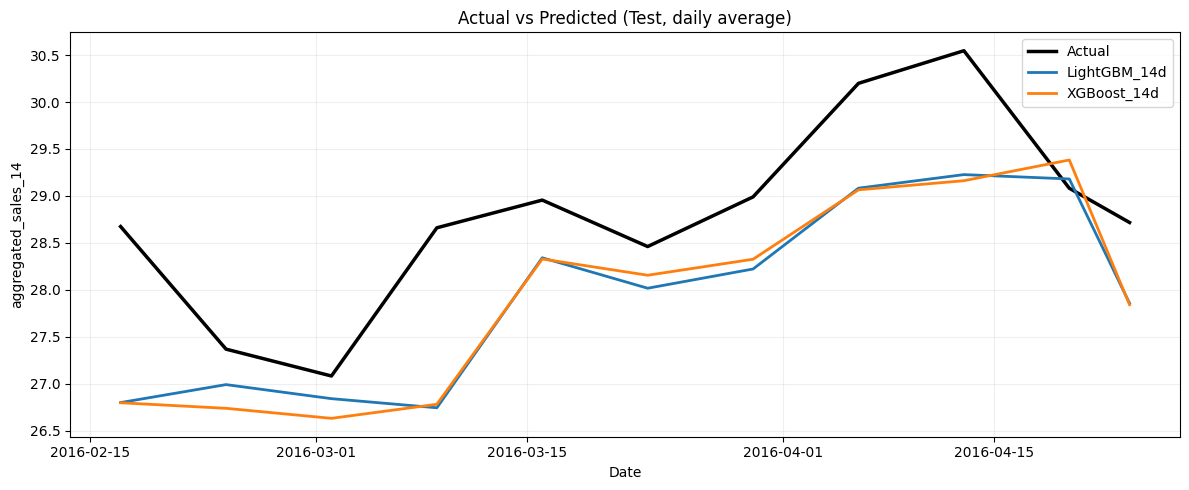

In [6]:
plot_df = test_df[['date']].copy()
plot_df['actual'] = y_test.values
for name, p in preds_test.items():
    plot_df[name] = p

daily = plot_df.groupby('date', as_index=False).mean(numeric_only=True).sort_values('date')

plt.figure(figsize=(12, 5))
plt.plot(daily['date'], daily['actual'], label='Actual', linewidth=2.5, color='black')
plt.plot(daily['date'], daily['LightGBM_14d'], label='LightGBM_14d', linewidth=2)
plt.plot(daily['date'], daily['XGBoost_14d'], label='XGBoost_14d', linewidth=2)
plt.title('Actual vs Predicted (Test, daily average)')
plt.xlabel('Date')
plt.ylabel('aggregated_sales_14')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 7) Residual Distributions (Test)
This cell compares error distributions (`prediction - actual`) for both models on the test split.

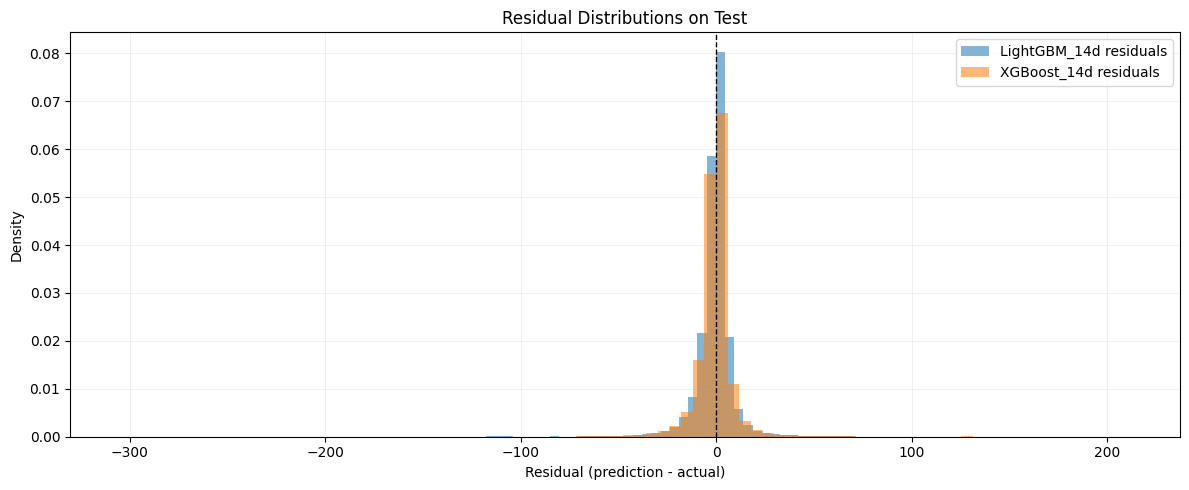

In [7]:
res_lgbm = preds_test['LightGBM_14d'] - y_test.values
res_xgb = preds_test['XGBoost_14d'] - y_test.values

plt.figure(figsize=(12, 5))
plt.hist(res_lgbm, bins=80, alpha=0.55, label='LightGBM_14d residuals', density=True)
plt.hist(res_xgb, bins=80, alpha=0.55, label='XGBoost_14d residuals', density=True)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Distributions on Test')
plt.xlabel('Residual (prediction - actual)')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 8) Save Comparison Artifacts
This cell saves metrics and test predictions to `artifacts/reports` for tracking and later review.

In [8]:
metrics_path = REPORTS_DIR / 'metrics_lgbm_xgb_14d_comparison.csv'
metrics_df.to_csv(metrics_path, index=False)

preds_out = test_df[['item_id', 'date']].copy()
preds_out['actual'] = y_test.values
preds_out['pred_lgbm_14d'] = preds_test['LightGBM_14d']
preds_out['pred_xgb_14d'] = preds_test['XGBoost_14d']

preds_path = REPORTS_DIR / 'predictions_lgbm_xgb_14d_test.csv'
preds_out.to_csv(preds_path, index=False)

print('Saved metrics to:', metrics_path)
print('Saved predictions to:', preds_path)

Saved metrics to: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports\metrics_lgbm_xgb_14d_comparison.csv
Saved predictions to: C:\Users\amrok\Desktop\Thesis\Project_XAI\xai-retail-replenishment\artifacts\reports\predictions_lgbm_xgb_14d_test.csv


In [11]:
actual_mean = train_df.groupby('item_id')['aggregated_sales_14'].mean()
stored_mean = train_df.groupby('item_id')['item_mean_train'].first()
print(pd.DataFrame({'actual': actual_mean, 'stored': stored_mean}).head(10))

                 actual      stored
item_id                            
FOODS_1_001    8.595745    8.595745
FOODS_1_002    6.063830    6.063830
FOODS_1_003    9.936170    9.936170
FOODS_1_004  177.744681  177.744681
FOODS_1_005   12.361702   12.361702
FOODS_1_006   22.468085   22.468085
FOODS_1_008    6.893617    6.893617
FOODS_1_009   10.063830   10.063830
FOODS_1_010    3.744681    3.744681
FOODS_1_011   13.425532   13.425532


In [12]:
from pathlib import Path

df = pd.read_csv(Path('..') / 'data' / 'processed' / 'lgbm_14' / 'train.csv')

# Check what values the lag and rolling features actually have now
print('=== Sample of rebuilt features ===')
print(df[['item_id', 'date', 'aggregated_sales_14',
          'sales_lag_14', 'sales_lag_7',
          'sales_roll_mean_14', 'sales_roll_mean_7']].head(20).to_string())

# Check how many zeros there are
lag_roll_cols = [c for c in df.columns if 'lag' in c or 'roll' in c]
print('\n=== Zero % per lag/rolling feature ===')
for col in lag_roll_cols:
    zero_pct = (df[col] == 0).mean() * 100
    print(f'{col}: {zero_pct:.1f}% zeros')

# Check NaN counts
print('\n=== NaN counts ===')
print(df[lag_roll_cols].isna().sum())

=== Sample of rebuilt features ===
        item_id        date  aggregated_sales_14  sales_lag_14  sales_lag_7  sales_roll_mean_14  sales_roll_mean_7
0   FOODS_1_001  2015-01-14                 13.0           0.0          0.0                 0.0                0.0
1   FOODS_1_001  2015-01-21                 11.0           0.0         13.0                13.0               13.0
2   FOODS_1_001  2015-01-28                  5.0          13.0         11.0                12.0               11.0
3   FOODS_1_001  2015-02-04                  8.0          11.0          5.0                 8.0                5.0
4   FOODS_1_001  2015-02-11                  9.0           5.0          8.0                 6.5                8.0
5   FOODS_1_001  2015-02-18                 14.0           8.0          9.0                 8.5                9.0
6   FOODS_1_001  2015-02-25                 11.0           9.0         14.0                11.5               14.0
7   FOODS_1_001  2015-03-04                  

In [13]:
print(df[['aggregated_sales_14', 'sales_lag_1', 'sales_lag_2', 'sales_lag_4']].head(10).to_string())

   aggregated_sales_14  sales_lag_1  sales_lag_2  sales_lag_4
0                 13.0          0.0          0.0          0.0
1                 11.0         13.0         13.0         13.0
2                  5.0         11.0         11.0         11.0
3                  8.0          5.0          5.0          5.0
4                  9.0          8.0          8.0          8.0
5                 14.0          9.0          9.0          9.0
6                 11.0         14.0         14.0         14.0
7                  4.0         11.0         11.0         11.0
8                 12.0          4.0          4.0          4.0
9                 17.0         12.0         12.0         12.0


In [14]:
print(df[['sales_roll_mean_2', 'sales_roll_mean_4', 'sales_roll_mean_7']].head(10).to_string())

   sales_roll_mean_2  sales_roll_mean_4  sales_roll_mean_7
0                0.0                0.0                0.0
1               13.0               13.0               13.0
2               11.0               11.0               11.0
3                5.0                5.0                5.0
4                8.0                8.0                8.0
5                9.0                9.0                9.0
6               14.0               14.0               14.0
7               11.0               11.0               11.0
8                4.0                4.0                4.0
9               12.0               12.0               12.0


In [15]:
print(df[['sales_roll_std_4', 'sales_roll_std_14']].head(10).to_string())
print('\nIdentical across full df?:', bool((df['sales_roll_std_4'] == df['sales_roll_std_14']).all()))

   sales_roll_std_4  sales_roll_std_14
0               0.0           0.000000
1               0.0           0.000000
2               0.0           1.414214
3               0.0           4.242641
4               0.0           2.121320
5               0.0           0.707107
6               0.0           3.535534
7               0.0           2.121320
8               0.0           4.949747
9               0.0           5.656854

Identical across full df?: False
